# Self-consuming loops: metrics analysis

Reads every metrics `.json` written by `consume.py`, merges runs, and produces figures.

**How merging works.** Each invocation writes `<model>-mix<pct>-<lineage>-<timestamp>.json`.
A restarted or resumed run therefore produces a *new* file for the same condition, and a
resumed run re-scores its starting generation, so the same `(condition, generation)` can
appear in more than one file. Rows are keyed on `(model, lineage, real_fraction, generation)`
and the **most recently written** row wins. Duplicates with differing values are reported so
nothing is dropped silently.

A condition is `mix<pct>` for the synthetic lineage and `real` for the control, which is
equivalent to 100% real data — so all conditions sit on a single real-fraction axis
(0, 10, 25, 50, 75, 90, 100).

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- point this at the metrics directory written by consume.py -------------------------
METRICS_DIR = Path("/research/nfs_khalili_17/gupte.31/selfconsuming/sae-robustness-under-self-consuming-models/generations/runs/metrics")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# ICLR style
FULL_W, HALF_W = 5.5, 2.7

pd.set_option("display.width", 200, "display.max_columns", 50)
print("metrics dir:", METRICS_DIR, "| exists:", METRICS_DIR.exists())

metrics dir: /research/nfs_khalili_17/gupte.31/selfconsuming/sae-robustness-under-self-consuming-models/generations/runs/metrics | exists: True


## 1. What files are on disk

In [4]:
files = sorted(METRICS_DIR.glob("*.json"))
records, inventory = [], []

for f in files:
    blob = json.loads(f.read_text())
    recs = blob.get("checkpoints", [])
    for r in recs:
        r["_file"] = f.name
    records += recs
    gens = [r["generation"] for r in recs] or [None]
    inventory.append({
        "file": f.name,
        "run_name": blob.get("run_name"),
        "started": f"{blob.get('run_started_date')} {blob.get('run_started_time')}",
        "rows": len(recs),
        "gens": f"{min(gens)}-{max(gens)}" if recs else "-",
    })

inv = pd.DataFrame(inventory).sort_values("started").reset_index(drop=True)
print(f"{len(files)} file(s), {len(records)} checkpoint row(s)")
inv

16 file(s), 90 checkpoint row(s)


,file,run_name,started,rows,gens
0,p160m-mix0-real-20260814-115732.json,p160m-mix0-real-20260814-115732,2026-08-14 11:57:32,6,0-5
1,p160m-mix0-synthetic-20260814-120435.json,p160m-mix0-synthetic-20260814-120435,2026-08-14 12:04:35,6,0-5
2,p160m-mix0-synthetic-20260814-133854.json,p160m-mix0-synthetic-20260814-133854,2026-08-14 13:38:54,6,5-10
3,p160m-mix0-real-20260814-134315.json,p160m-mix0-real-20260814-134315,2026-08-14 13:43:15,6,5-10
4,p160m-mix10-synthetic-20260814-135049.json,p160m-mix10-synthetic-20260814-135049,2026-08-14 13:50:49,6,0-5
5,p160m-mix25-synthetic-20260814-135049.json,p160m-mix25-synthetic-20260814-135049,2026-08-14 13:50:49,4,0-3
6,p160m-mix50-synthetic-20260814-135049.json,p160m-mix50-synthetic-20260814-135049,2026-08-14 13:50:49,6,0-5
7,p160m-mix75-synthetic-20260814-135049.json,p160m-mix75-synthetic-20260814-135049,2026-08-14 13:50:49,9,0-8
8,p160m-mix90-synthetic-20260814-135049.json,p160m-mix90-synthetic-20260814-135049,2026-08-14 13:50:49,11,0-10
9,p160m-mix10-synthetic-20260814-170215.json,p160m-mix10-synthetic-20260814-170215,2026-08-14 17:02:15,2,4-5


## 2. Merge into one tidy table

In [5]:
METRICS = ["perplexity", "real_loss", "output_entropy_nats", "output_entropy_bits",
           "distinct_1", "distinct_2", "distinct_3", "distinct_4"]

raw = pd.DataFrame(records)
raw["timestamp"] = pd.to_datetime(raw["timestamp"], format="ISO8601", errors="coerce")
if raw["timestamp"].isna().any():          # fall back to the file's start time
    starts = inv.set_index("file")["started"]
    fb = pd.to_datetime(raw["_file"].map(starts), errors="coerce")
    raw["timestamp"] = raw["timestamp"].fillna(fb)
    print(f"note: {int(fb.notna().sum())} row(s) had an unparsable timestamp; "
          "used the file start time for ordering")

# the control is the 100%-real end of the mixing axis
raw["real_fraction"] = np.where(raw["lineage"].eq("real"), 100.0, raw["real_percent"])
raw["condition"] = np.where(raw["lineage"].eq("real"), "real",
                            "mix" + raw["real_percent"].map(lambda p: f"{p:g}"))

KEY = ["model", "lineage", "real_fraction", "generation"]

# report duplicates whose values actually disagree before collapsing them
dupes = raw[raw.duplicated(KEY, keep=False)]
if len(dupes):
    spread = (dupes.groupby(KEY)[["perplexity", "output_entropy_nats"]]
                   .agg(lambda s: s.max() - s.min()).reset_index())
    disagree = spread[(spread["perplexity"] > 1e-6) | (spread["output_entropy_nats"] > 1e-6)]
    print(f"{len(dupes)} duplicated row(s) across files; "
          f"{len(disagree)} with differing values (re-scored on resume) -> keeping newest:")
    if len(disagree):
        display(disagree)
else:
    print("no duplicated (condition, generation) rows")

df = (raw.sort_values("timestamp")
         .drop_duplicates(KEY, keep="last")
         .sort_values(["real_fraction", "generation"])
         .reset_index(drop=True))

ORDER = sorted(df["condition"].unique(),
               key=lambda c: df.loc[df.condition.eq(c), "real_fraction"].iloc[0])
df["condition"] = pd.Categorical(df["condition"], ORDER, ordered=True)

print(f"\n{len(df)} unique checkpoints | conditions: {ORDER}")
df[["condition", "real_fraction", "generation", "perplexity",
    "output_entropy_nats", "distinct_4", "_file"]].head(20)

24 duplicated row(s) across files; 4 with differing values (re-scored on resume) -> keeping newest:


,model,lineage,real_fraction,generation,perplexity,output_entropy_nats
3,EleutherAI/pythia-160m-deduped,synthetic,10.0,5,0.1441,0.196126
5,EleutherAI/pythia-160m-deduped,synthetic,25.0,3,0.1933,0.194758
8,EleutherAI/pythia-160m-deduped,synthetic,50.0,5,0.1484,0.153272
10,EleutherAI/pythia-160m-deduped,synthetic,75.0,8,0.1049,0.164237



77 unique checkpoints | conditions: ['mix0', 'mix10', 'mix25', 'mix50', 'mix75', 'mix90', 'real']


,condition,real_fraction,generation,perplexity,output_entropy_nats,distinct_4,_file
0,mix0,0.0,0,26.8982,3.177778,0.922550,p160m-mix0-synthetic-20260814-120435.json
1,mix0,0.0,1,26.5141,2.571883,0.801848,p160m-mix0-synthetic-20260814-120435.json
2,mix0,0.0,2,26.4776,2.412676,0.789078,p160m-mix0-synthetic-20260814-120435.json
3,mix0,0.0,3,26.2259,1.920007,0.641638,p160m-mix0-synthetic-20260814-120435.json
4,mix0,0.0,4,26.8083,1.898233,0.670586,p160m-mix0-synthetic-20260814-120435.json
5,mix0,0.0,5,27.0094,1.338932,0.487475,p160m-mix0-synthetic-20260814-133854.json
6,mix0,0.0,6,27.0827,1.361621,0.470193,p160m-mix0-synthetic-20260814-133854.json
7,mix0,0.0,7,27.2808,0.758742,0.262985,p160m-mix0-synthetic-20260814-133854.json
8,mix0,0.0,8,27.5094,0.470362,0.161990,p160m-mix0-synthetic-20260814-133854.json
9,mix0,0.0,9,27.4237,0.442731,0.082638,p160m-mix0-synthetic-20260814-133854.json


## 3. One table per metric

In [6]:
def wide(metric):
    return (df.pivot_table(index="condition", columns="generation",
                           values=metric, observed=True)
              .round(3))

for m in ["perplexity", "output_entropy_nats", "distinct_1", "distinct_4"]:
    print(f"\n=== {m} ===")
    display(wide(m))


=== perplexity ===


generation,0,1,2,3,4,5,6,7,8,9,10
condition,,,,,,,,,,,
mix0,26.898,26.514,26.478,26.226,26.808,27.009,27.083,27.281,27.509,27.424,27.867
mix10,26.898,26.498,26.567,26.538,26.182,26.420,26.508,26.264,26.421,26.199,26.458
mix25,26.898,26.461,26.325,25.989,26.077,25.910,26.198,26.248,26.089,26.220,26.131
mix50,26.898,26.334,26.050,26.092,26.131,26.052,26.010,26.015,25.998,25.947,26.096
mix75,26.898,26.202,25.928,25.941,25.852,25.972,26.018,25.958,25.944,25.768,25.944
mix90,26.898,26.260,25.832,25.946,25.834,25.748,25.579,25.566,25.796,25.773,25.693
real,26.898,26.190,26.233,26.048,26.156,25.971,25.734,25.794,26.018,25.862,26.133



=== output_entropy_nats ===


generation,0,1,2,3,4,5,6,7,8,9,10
condition,,,,,,,,,,,
mix0,3.178,2.572,2.413,1.920,1.898,1.339,1.362,0.759,0.470,0.443,0.437
mix10,3.178,2.509,1.903,1.663,1.368,1.339,1.244,0.740,0.599,0.387,0.351
mix25,3.178,2.665,2.538,2.022,1.741,1.866,1.672,1.241,1.157,0.882,0.726
mix50,3.178,2.681,2.252,1.935,1.731,1.748,1.645,1.250,1.471,1.305,1.191
mix75,3.178,2.695,2.265,2.174,2.016,1.805,2.013,1.832,1.824,1.587,1.498
mix90,3.178,2.405,2.395,2.379,2.390,2.258,2.348,2.255,2.300,2.381,2.116
real,3.178,2.633,2.474,2.468,2.362,2.332,2.405,2.284,2.414,2.284,2.380



=== distinct_1 ===


generation,0,1,2,3,4,5,6,7,8,9,10
condition,,,,,,,,,,,
mix0,0.16,0.116,0.092,0.091,0.069,0.050,0.065,0.038,0.020,0.009,0.006
mix10,0.16,0.106,0.081,0.081,0.070,0.058,0.059,0.047,0.032,0.010,0.005
mix25,0.16,0.124,0.097,0.069,0.050,0.069,0.049,0.043,0.036,0.041,0.034
mix50,0.16,0.118,0.120,0.070,0.068,0.077,0.057,0.055,0.059,0.052,0.061
mix75,0.16,0.128,0.092,0.107,0.102,0.085,0.088,0.090,0.088,0.062,0.059
mix90,0.16,0.105,0.117,0.124,0.101,0.099,0.081,0.082,0.093,0.117,0.081
real,0.16,0.079,0.113,0.117,0.108,0.114,0.104,0.103,0.124,0.109,0.107



=== distinct_4 ===


generation,0,1,2,3,4,5,6,7,8,9,10
condition,,,,,,,,,,,
mix0,0.923,0.802,0.789,0.642,0.671,0.487,0.470,0.263,0.162,0.083,0.041
mix10,0.923,0.791,0.649,0.587,0.490,0.463,0.472,0.273,0.203,0.084,0.037
mix25,0.923,0.857,0.848,0.686,0.592,0.652,0.591,0.441,0.419,0.300,0.251
mix50,0.923,0.846,0.780,0.649,0.585,0.602,0.590,0.447,0.521,0.459,0.426
mix75,0.923,0.851,0.738,0.739,0.703,0.661,0.694,0.627,0.654,0.555,0.528
mix90,0.923,0.791,0.826,0.815,0.803,0.788,0.784,0.773,0.759,0.820,0.729
real,0.923,0.873,0.859,0.823,0.795,0.802,0.781,0.773,0.809,0.795,0.781


## 4. Summary: first vs last generation

`delta` is last minus first within a condition. `excess` subtracts the real control's delta
over the same generation span — the control moves too (repeated fine-tuning sharpens a model
even on real data), so excess is the part attributable to self-consumption.

In [7]:
def summarize(metric):
    rows = []
    for cond, g in df.groupby("condition", observed=True):
        g = g.sort_values("generation")
        rows.append({"condition": cond, "real_fraction": g["real_fraction"].iloc[0],
                     "gen_first": g["generation"].iloc[0], "gen_last": g["generation"].iloc[-1],
                     "first": g[metric].iloc[0], "last": g[metric].iloc[-1],
                     "delta": g[metric].iloc[-1] - g[metric].iloc[0]})
    out = pd.DataFrame(rows)
    if (out.condition == "real").any():
        ctrl = out.loc[out.condition.eq("real"), "delta"].iloc[0]
        out["excess"] = out["delta"] - ctrl
    return out.round(4)

for m in ["perplexity", "output_entropy_nats", "distinct_4"]:
    print(f"\n=== {m} ===")
    display(summarize(m))


=== perplexity ===


,condition,real_fraction,gen_first,gen_last,first,last,delta,excess
0,mix0,0.0,0,10,26.8982,27.8674,0.9692,1.7342
1,mix10,10.0,0,10,26.8982,26.4579,-0.4403,0.3247
2,mix25,25.0,0,10,26.8982,26.1308,-0.7674,-0.0024
3,mix50,50.0,0,10,26.8982,26.0962,-0.8020,-0.0370
4,mix75,75.0,0,10,26.8982,25.9445,-0.9537,-0.1887
5,mix90,90.0,0,10,26.8982,25.6934,-1.2048,-0.4398
6,real,100.0,0,10,26.8982,26.1332,-0.7650,0.0000



=== output_entropy_nats ===


,condition,real_fraction,gen_first,gen_last,first,last,delta,excess
0,mix0,0.0,0,10,3.1778,0.4372,-2.7406,-1.9426
1,mix10,10.0,0,10,3.1778,0.3512,-2.8266,-2.0286
2,mix25,25.0,0,10,3.1778,0.7263,-2.4515,-1.6535
3,mix50,50.0,0,10,3.1778,1.1911,-1.9867,-1.1887
4,mix75,75.0,0,10,3.1778,1.4975,-1.6802,-0.8823
5,mix90,90.0,0,10,3.1778,2.1162,-1.0616,-0.2636
6,real,100.0,0,10,3.1778,2.3798,-0.7980,0.0000



=== distinct_4 ===


,condition,real_fraction,gen_first,gen_last,first,last,delta,excess
0,mix0,0.0,0,10,0.9226,0.0410,-0.8815,-0.7405
1,mix10,10.0,0,10,0.9226,0.0374,-0.8852,-0.7441
2,mix25,25.0,0,10,0.9226,0.2511,-0.6715,-0.5304
3,mix50,50.0,0,10,0.9226,0.4261,-0.4965,-0.3554
4,mix75,75.0,0,10,0.9226,0.5285,-0.3941,-0.2530
5,mix90,90.0,0,10,0.9226,0.7292,-0.1934,-0.0523
6,real,100.0,0,10,0.9226,0.7815,-0.1411,0.0000


## 5. Figure style

In [8]:
mpl.rcParams.update({
    "font.family": "serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 6.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.6, "lines.linewidth": 1.2, "lines.markersize": 3,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "legend.frameon": False, "figure.dpi": 130, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.01,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

CTRL_C = "black"
_cmap = plt.get_cmap("viridis")

def colour(frac):
    # sequential colour by real-data fraction; the control is drawn black
    return CTRL_C if frac >= 100 else _cmap(0.08 + 0.72 * frac / 100)

def style(cond, frac):
    return dict(color=colour(frac),
                linestyle="--" if cond == "real" else "-",
                marker="s" if cond == "real" else "o",
                label="real control" if cond == "real" else f"{frac:g}% real")

PANELS = [("perplexity", "Perplexity (real data)"),
          ("output_entropy_nats", "Output entropy (nats)"),
          ("distinct_4", "Distinct-4 (own samples)")]

def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    print("wrote", FIG_DIR / f"{name}.pdf")

## 6. Visualizations

### All metrics
Adjust X and Y to compare desired settings.

wrote figures/gen0-10_mix0_real.pdf


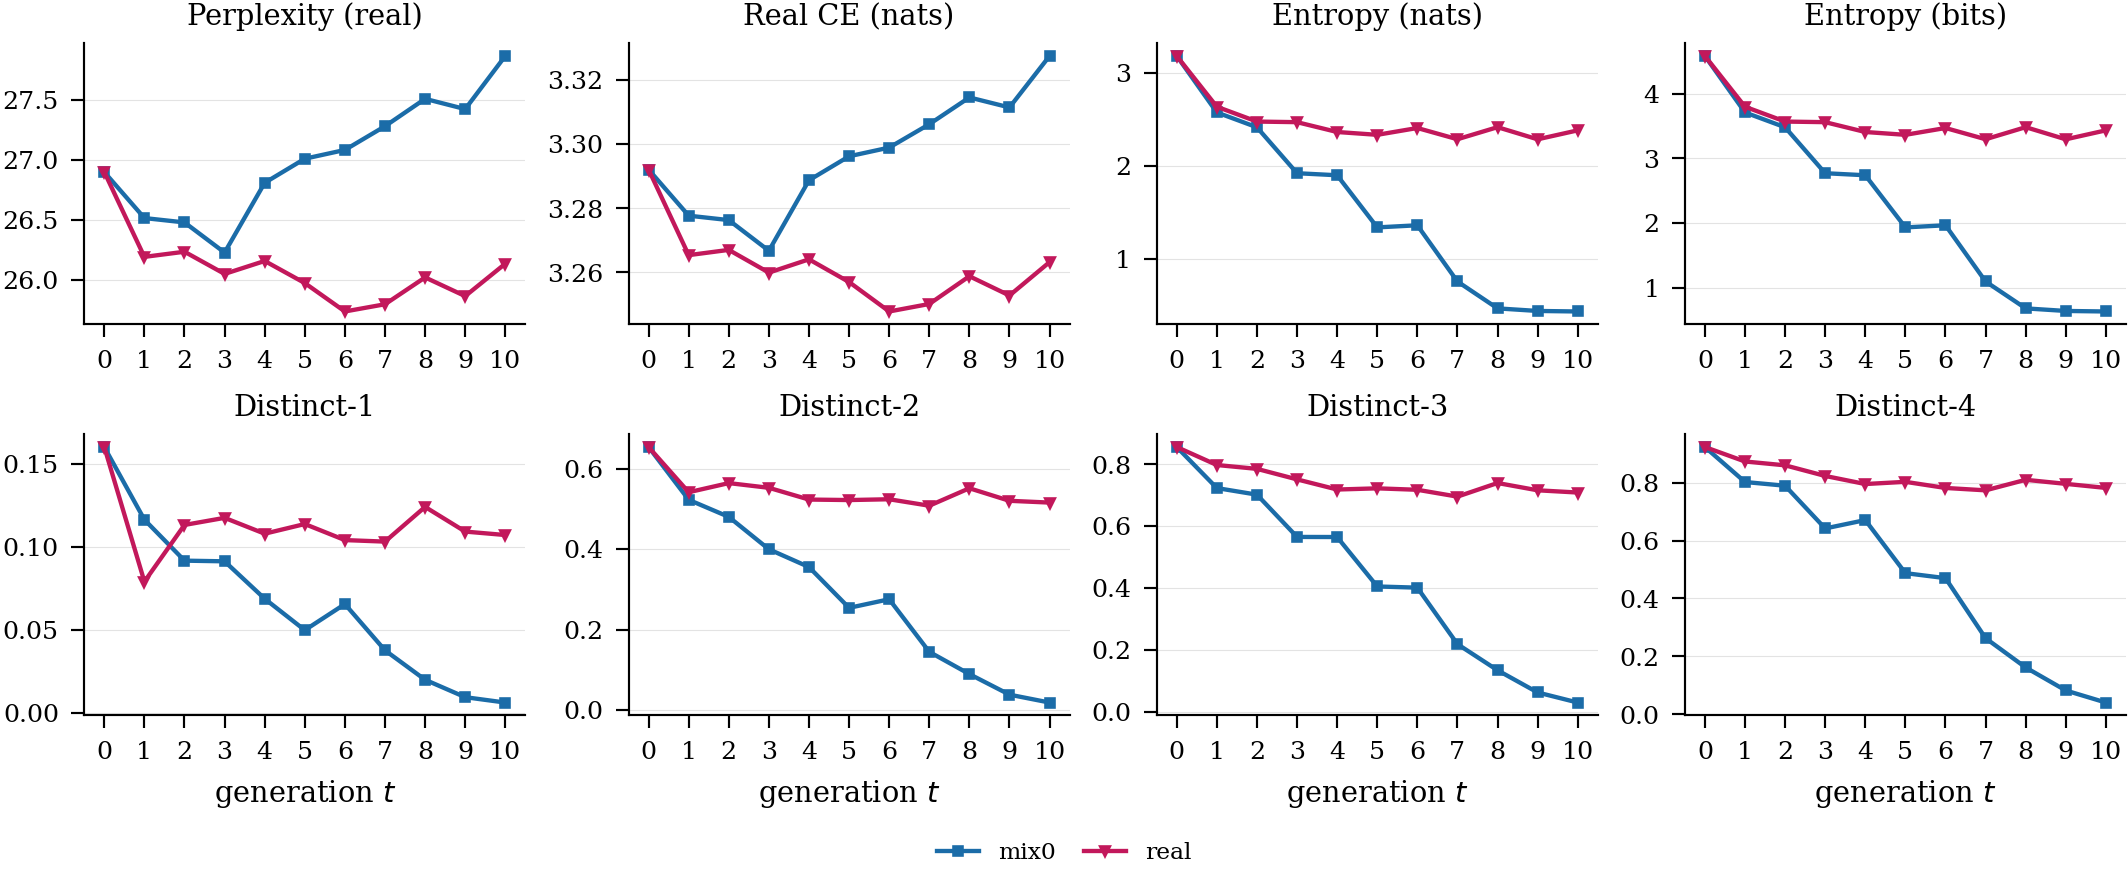

condition               mix0   real
           generation              
distinct_1 0           0.160  0.160
           1           0.116  0.079
           2           0.092  0.113
           3           0.091  0.117
           4           0.069  0.108
...                      ...    ...
real_loss  6           3.299  3.248
           7           3.306  3.250
           8           3.315  3.259
           9           3.311  3.253
           10          3.327  3.263

[88 rows x 2 columns]

In [36]:
mpl.rcParams["figure.dpi"] = 260   
# ---- all 8 metrics in a 2x4 grid: generations 0..X, conditions Y ----------------------

X = 10                                   # last generation to show
Y = ["mix0", "real"]           # one or more conditions; a bare string also works

LABELS = {"perplexity": "Perplexity (real)", "real_loss": "Real CE (nats)",
          "output_entropy_nats": "Entropy (nats)", "output_entropy_bits": "Entropy (bits)",
          "distinct_1": "Distinct-1", "distinct_2": "Distinct-2",
          "distinct_3": "Distinct-3", "distinct_4": "Distinct-4"}

conds = [Y] if isinstance(Y, str) else list(Y)
available = set(df["condition"].astype(str))
missing = [c for c in conds if c not in available]
assert not missing, f"unknown condition(s) {missing}; available: {ORDER}"

sub = df[df["condition"].astype(str).isin(conds) & df["generation"].le(X)]
assert len(sub), f"no rows for {conds} at generations 0-{X}"

# random but reproducible colour/marker per condition set
rng = np.random.default_rng(abs(hash(tuple(conds))) % (2**32))
PALETTE = ["#1b6ca8", "#c1440e", "#2a9d3f", "#7b3fa0", "#d19100",
           "#0b8a8f", "#c2185b", "#5d4037", "#455a64"]
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<"]
cols = rng.permutation(PALETTE)[:len(conds)]
mks = rng.permutation(MARKERS)[:len(conds)]
STYLE = {c: dict(color=cols[i], marker=mks[i], linestyle="-", label=c, markersize=2)
         for i, c in enumerate(conds)}

fig, axes = plt.subplots(2, 4, figsize=(1.5 * FULL_W, 1.1 * 2.9), constrained_layout=True)
for ax, metric in zip(axes.ravel(), METRICS):
    for cond in conds:                                  # fixed order -> stable legend
        g = sub[sub["condition"].astype(str).eq(cond)].sort_values("generation")
        ax.plot(g["generation"], g[metric], **STYLE[cond])
    ax.set_title(LABELS.get(metric, metric), pad=5)
    ax.set_xticks(sorted(sub["generation"].unique()))
    ax.grid(axis="y", lw=0.3, alpha=0.35)
for ax in axes[-1]:
    ax.set_xlabel("generation $t$")

# fig.suptitle(f"Generations 0–{X}  | Conditions " + ", ".join(conds), fontsize=10)

handles = [Line2D([], [], **STYLE[c]) for c in conds]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0),
           ncol=min(len(conds), 7), columnspacing=1.2, handlelength=1.8)

name = f"gen0-{X}_" + "_".join(conds)
save(fig, name)
plt.show()

display(sub.pivot_table(index="condition", columns="generation",
                        values=METRICS, observed=True).round(3).T)

### Single metric

wrote figures/output_entropy_nats_gen0-10_mix0_real.pdf


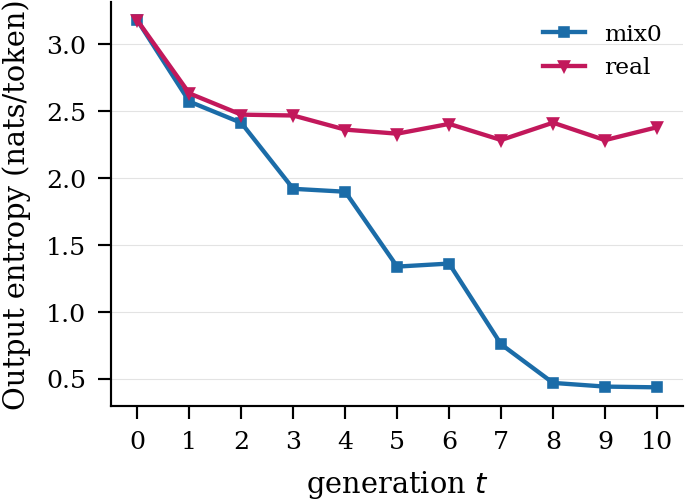

generation,0,1,2,3,4,5,6,7,8,9,10
condition,,,,,,,,,,,
mix0,3.1778,2.5719,2.4127,1.9200,1.8982,1.3389,1.3616,0.7587,0.4704,0.4427,0.4372
real,3.1778,2.6330,2.4740,2.4676,2.3621,2.3318,2.4049,2.2845,2.4139,2.2836,2.3798


In [43]:
# ---- one metric, single panel: generations 0..X, conditions Y, metric Z ---------------
X = 10                                   # last generation to show
Y = ["mix0", "real"]           # one or more conditions; a bare string also works
Z = "output_entropy_nats"               # any column in METRICS

LABELS = {"perplexity": "Perplexity (real data)",
          "real_loss": "Cross-entropy on real data (nats)",
          "output_entropy_nats": "Output entropy (nats/token)",
          "output_entropy_bits": "Output entropy (bits/token)",
          "distinct_1": "Distinct-1 (own samples)",
          "distinct_2": "Distinct-2 (own samples)",
          "distinct_3": "Distinct-3 (own samples)",
          "distinct_4": "Distinct-4 (own samples)"}

conds = [Y] if isinstance(Y, str) else list(Y)
available = set(df["condition"].astype(str))
missing = [c for c in conds if c not in available]
assert not missing, f"unknown condition(s) {missing}; available: {ORDER}"
assert Z in df.columns, f"unknown metric {Z}; available: {METRICS}"

sub = df[df["condition"].astype(str).isin(conds) & df["generation"].le(X)]
assert len(sub), f"no rows for {conds} at generations 0-{X}"

# random but reproducible colour/marker per condition set
rng = np.random.default_rng(abs(hash(tuple(conds))) % (2**32))
PALETTE = ["#1b6ca8", "#c1440e", "#2a9d3f", "#7b3fa0", "#d19100",
           "#0b8a8f", "#c2185b", "#5d4037", "#455a64"]
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<"]
cols = rng.permutation(PALETTE)[:len(conds)]
mks = rng.permutation(MARKERS)[:len(conds)]
STYLE = {c: dict(color=cols[i], marker=mks[i], linestyle="-", label=c, markersize=2)
         for i, c in enumerate(conds)}

fig, ax = plt.subplots(figsize=(HALF_W, 2.0), constrained_layout=True)
for cond in conds:                                      # fixed order -> stable legend
    g = sub[sub["condition"].astype(str).eq(cond)].sort_values("generation")
    ax.plot(g["generation"], g[Z], **STYLE[cond])
ax.set_xlabel("generation $t$")
ax.set_ylabel(LABELS.get(Z, Z))
ax.set_xticks(sorted(sub["generation"].unique()))
ax.grid(axis="y", lw=0.3, alpha=0.35)
# ax.set_title(f"Generations 0–{X}  | Conditions: " + ", ".join(conds), fontsize=8, pad=4)
if len(conds) > 1:
    ax.legend(handlelength=1.8)

name = f"{Z}_gen0-{X}_" + "_".join(conds)
save(fig, name)
plt.show()

display(sub.pivot_table(index="condition", columns="generation",
                        values=Z, observed=True).round(4))

### Figure - Heatmap

Every condition × generation for the two collapse metrics, as a compact heatmap. Useful as a
supplementary figure or for spotting non-monotonicity that the line plots hide.

wrote figures/heatmap_output_entropy_nats_gen0-10.pdf


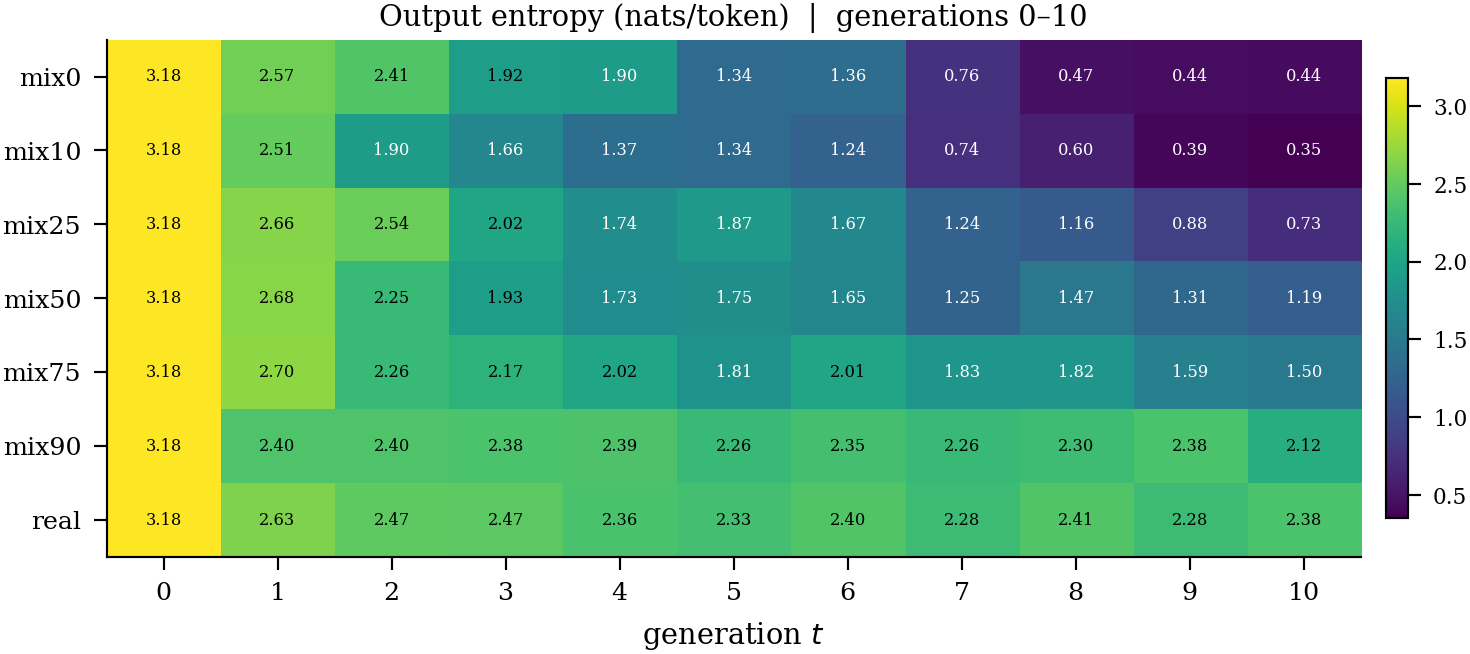

generation,0,1,2,3,4,5,6,7,8,9,10
condition,,,,,,,,,,,
mix0,3.1778,2.5719,2.4127,1.9200,1.8982,1.3389,1.3616,0.7587,0.4704,0.4427,0.4372
mix10,3.1778,2.5089,1.9034,1.6632,1.3683,1.3389,1.2439,0.7403,0.5985,0.3867,0.3512
mix25,3.1778,2.6647,2.5380,2.0223,1.7409,1.8659,1.6718,1.2410,1.1568,0.8816,0.7263
mix50,3.1778,2.6809,2.2519,1.9345,1.7310,1.7480,1.6452,1.2500,1.4709,1.3054,1.1911
mix75,3.1778,2.6952,2.2647,2.1737,2.0160,1.8052,2.0134,1.8321,1.8243,1.5866,1.4975
mix90,3.1778,2.4048,2.3951,2.3786,2.3905,2.2578,2.3478,2.2553,2.2999,2.3812,2.1162
real,3.1778,2.6330,2.4740,2.4676,2.3621,2.3318,2.4049,2.2845,2.4139,2.2836,2.3798


In [42]:
# ---- heatmap: one metric, all conditions, generations 0..X ----------------------------
X = 10                                   # last generation to show
Z = "output_entropy_nats"               # any column in METRICS
CMAP = {"perplexity": "magma_r", "real_loss": "magma_r"}.get(Z, "viridis")

LABELS = {"perplexity": "Perplexity (real data)",
          "real_loss": "Cross-entropy on real data (nats)",
          "output_entropy_nats": "Output entropy (nats/token)",
          "output_entropy_bits": "Output entropy (bits/token)",
          "distinct_1": "Distinct-1 (own samples)",
          "distinct_2": "Distinct-2 (own samples)",
          "distinct_3": "Distinct-3 (own samples)",
          "distinct_4": "Distinct-4 (own samples)"}

assert Z in df.columns, f"unknown metric {Z}; available: {METRICS}"

w = (df[df["generation"].le(X)]
       .pivot_table(index="condition", columns="generation", values=Z, observed=True))
assert w.size, f"no rows at generations 0-{X}"

fig, ax = plt.subplots(figsize=(1.1 + 0.42 * len(w.columns), 0.9 + 0.24 * len(w.index)),
                       constrained_layout=True)
im = ax.imshow(w.values, aspect="auto", cmap=CMAP)
ax.set_xticks(range(len(w.columns)), w.columns)
ax.set_yticks(range(len(w.index)), w.index)
ax.set_xlabel("generation $t$")
ax.set_title(f"{LABELS.get(Z, Z)}  |  generations 0–{X}", pad=4)

for i in range(w.shape[0]):
    for j in range(w.shape[1]):
        v = w.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=4.5,
                    color="white" if im.norm(v) < 0.55 else "black")

fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02).ax.tick_params(labelsize=6)

name = f"heatmap_{Z}_gen0-{X}"
save(fig, name)
plt.show()

display(w.round(4))

wrote figures/excess_bars_gen5_10.pdf


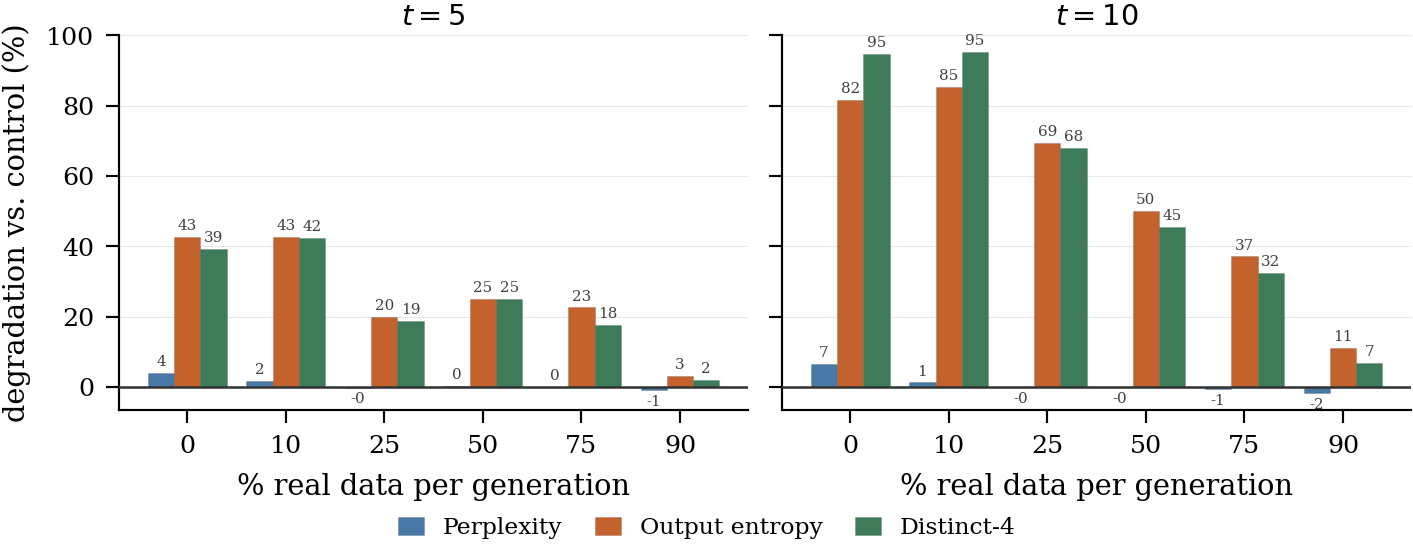


=== generation 5: degradation vs control (%) ===


,Perplexity,Output entropy,Distinct-4
condition,,,
mix0,4.00,42.58,39.25
mix10,1.73,42.58,42.31
mix25,-0.24,19.98,18.70
mix50,0.31,25.04,24.92
mix75,0.00,22.59,17.62
mix90,-0.86,3.18,1.87



=== generation 10: degradation vs control (%) ===


,Perplexity,Output entropy,Distinct-4
condition,,,
mix0,6.64,81.63,94.75
mix10,1.24,85.24,95.22
mix25,-0.01,69.48,67.87
mix50,-0.14,49.95,45.48
mix75,-0.72,37.07,32.37
mix90,-1.68,11.08,6.69


In [45]:
# ---- degradation vs control, two generations side by side -----------------------------
GENS = [5, 10]                      # exactly two panels
BAR_METRICS = [("perplexity", "Perplexity"),
               ("output_entropy_nats", "Output entropy"),
               ("distinct_4", "Distinct-4")]
WORSE_IF_HIGHER = {"perplexity", "real_loss"}   # higher than control = worse
BAR_COLS = ["#4878A6", "#C4622D", "#3E7C59"]    # muted blue / rust / green
EDGE = "#33333330"

def degradation(at, ctrl, conds, metric):
    c = ctrl[metric].iloc[0]
    v = []
    for cond in conds:
        s = at[at["condition"].astype(str).eq(cond)][metric].iloc[0]
        v.append(100 * (s - c) / abs(c) if metric in WORSE_IF_HIGHER
                 else 100 * (c - s) / abs(c))
    return np.array(v)

panels, tables = [], {}
for GEN in GENS:
    at = df[df["generation"].eq(GEN)]
    ctrl = at[at["condition"].astype(str).eq("real")]
    conds = [c for c in ORDER if c != "real" and c in set(at["condition"].astype(str))]
    if not len(ctrl) or not conds:
        print(f"gen {GEN}: missing control or conditions, panel will be empty")
    panels.append((GEN, at, ctrl, conds))
    if len(ctrl) and conds:
        tables[GEN] = pd.DataFrame({lab: degradation(at, ctrl, conds, m)
                                    for m, lab in BAR_METRICS}, index=conds)

fig, axes = plt.subplots(1, 2, figsize=(FULL_W, 2.0), sharey=True,
                         constrained_layout=True)

for ax, (GEN, at, ctrl, conds) in zip(axes, panels):
    if not len(ctrl) or not conds:
        ax.text(0.5, 0.5, f"generation {GEN}\nnot available", ha="center", va="center",
                fontsize=7, color="0.5", transform=ax.transAxes)
        ax.set_xticks([]); ax.set_title(f"$t = {GEN}$", pad=3); continue
    x, w = np.arange(len(conds)), 0.8 / len(BAR_METRICS)
    for k, (metric, label) in enumerate(BAR_METRICS):
        off = (k - (len(BAR_METRICS) - 1) / 2) * w
        b = ax.bar(x + off, degradation(at, ctrl, conds, metric), w, label=label,
                   color=BAR_COLS[k], edgecolor=EDGE, linewidth=0.3, zorder=3)
        ax.bar_label(b, fmt="%.0f", fontsize=4.2, padding=1.2, color="0.25")
    ax.axhline(0, color="0.2", lw=0.7, zorder=4)
    ax.set_xticks(x, [c.replace("mix", "") for c in conds])
    ax.set_xlabel("% real data per generation")
    ax.set_title(f"$t = {GEN}$", pad=3)
    ax.grid(axis="y", lw=0.3, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel("degradation vs. control (%)")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, 0.03),
           ncol=len(BAR_METRICS), handlelength=1.1, handleheight=0.8, columnspacing=1.4)

save(fig, "excess_bars_gen" + "_".join(str(g) for g in GENS))
plt.show()

for GEN, t in tables.items():
    print(f"\n=== generation {GEN}: degradation vs control (%) ===")
    display(t.round(2).rename_axis("condition"))